<a href="https://colab.research.google.com/github/derewor/Alzheimer-drug-discovery/blob/main/gamma_secretase_Alzheimer%20Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#**Connect with the chEMBL database**

In [ ]:
# import all target molecules from the chEMBL database
# first install the chEMBL database.
! pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
# import new-client
from chembl_webresource_client.new_client import new_client

In [ ]:
# import the target molecules form the chEMBL database.
target = new_client.target
target_df = pd.DataFrame(target.search('Alzheimer'))
target_df

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Nucleosome-remodeling factor subunit BPTF,13.0,False,CHEMBL3085621,"[{'accession': 'Q12830', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Homo sapiens,Nicastrin,12.0,False,CHEMBL3418,"[{'accession': 'Q92542', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Homo sapiens,Gamma-secretase,12.0,False,CHEMBL2094135,"[{'accession': 'Q96BI3', 'component_descriptio...",PROTEIN COMPLEX,9606
3,[],Homo sapiens,Protein cereblon/Nucleosome-remodeling factor ...,12.0,False,CHEMBL6195548,"[{'accession': 'Q12830', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Rattus norvegicus,Amyloid-beta precursor protein,9.0,False,CHEMBL3638365,"[{'accession': 'P08592', 'component_descriptio...",SINGLE PROTEIN,10116
5,[],Mus musculus,Amyloid-beta precursor protein,8.0,False,CHEMBL4523942,"[{'accession': 'P12023', 'component_descriptio...",SINGLE PROTEIN,10090
6,[],Homo sapiens,Amyloid-beta precursor protein,7.0,False,CHEMBL2487,"[{'accession': 'P05067', 'component_descriptio...",SINGLE PROTEIN,9606


In [ ]:
# select the target chambel_id
selected_target = target_df.target_chembl_id[2]
selected_target

'CHEMBL2094135'

In [ ]:
# Now extract the activity data for the selected target enzyme.
activity = new_client.activity
res_activity = activity.filter(target_chembl_id = selected_target)#.filter(standard_type = "IC50")
res_act_df = pd.DataFrame(res_activity)
res_act_df.shape

(4930, 47)

In [ ]:
# filter out rows where the actiity standard type is IC50
res_df = res_act_df.query('standard_type == "IC50"')
res_df.shape

(3546, 47)

In [ ]:
# sace the data as csv.
res_df.to_csv('gsecretase_bioactivity_data.csv', index=False)

## **1.Data Wrangling**

In [ ]:
res_df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [ ]:
# select only desired features
selected_columns = ['molecule_chembl_id', 'canonical_smiles','standard_units', 'standard_value','value','potential_duplicate','standard_type']
act_df = res_df[selected_columns]
act_df.head()

,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50


In [ ]:
# check the data types of the selected featuers
act_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3546 entries, 12 to 4929
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   molecule_chembl_id   3546 non-null   object
 1   canonical_smiles     3546 non-null   object
 2   standard_units       3517 non-null   object
 3   standard_value       3516 non-null   object
 4   value                3516 non-null   object
 5   potential_duplicate  3546 non-null   int64 
 6   standard_type        3546 non-null   object
dtypes: int64(1), object(6)
memory usage: 221.6+ KB


In [ ]:
# The standard value and value features need to be a float.
act_df['standard_value'] = act_df['standard_value'].astype(float)
act_df['value'] = act_df['value'].astype(float)
# Check if there are missing values in the dataframe, mainly in the chambl_id and standard_value. drop missing values.
act_df1 = act_df.dropna()
act_df1.shape

/tmp/ipykernel_2343/2260118385.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df['standard_value'] = act_df['standard_value'].astype(float)
/tmp/ipykernel_2343/2260118385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df['value'] = act_df['value'].astype(float)


(3516, 7)

In [ ]:
# check if there are duplicated values.
act_df1.potential_duplicate.value_counts().reset_index()

,potential_duplicate,count
0,0,3416
1,1,100


In [ ]:
# extract non duplicated entries.
act_df2 = act_df1.query("potential_duplicate == 0")
act_df2.shape

(3416, 7)

In [ ]:
# Describe the standard value of the filtered df.
act_df2.standard_value.describe() # the mean and median values indicate that the data is highly skewed.

,standard_value
count,3416.000000
mean,6134.732725
std,19177.447115
min,0.002000
25%,20.000000
50%,150.500000
75%,1640.000000
max,332000.000000


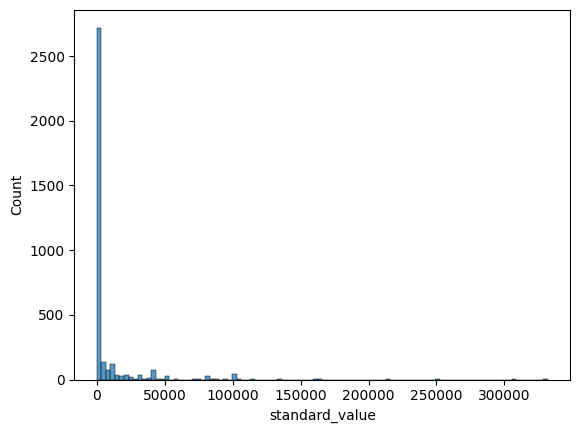

In [ ]:
# observe the distribution of the standard type.
sns.histplot(act_df2['standard_value'], bins=100)
plt.show()

In [ ]:
# define a function that categorizes molecule based on the standard value.
def activity_category(value):
  if value >= 10000:
    return 'inactive'
  elif value >= 1000:
    return 'weekly_active'
  elif value >= 100:
    return 'active'
  else:
    return 'potent'

act_df2['activity_class'] = act_df2['standard_value'].apply(activity_category)
act_df2.head()

/tmp/ipykernel_2343/3707800158.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['activity_class'] = act_df2['standard_value'].apply(activity_category)


,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type,activity_class
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50,potent
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50,potent
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50,potent
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50,potent
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50,weekly_active


In [ ]:
# convert the standard_values into Molar by multiplying with 10 -9
act_df2['IC50'] = act_df2['standard_value'] * 10**-9
# Then -log trasnform the ic50 feature.
act_df2['log_IC50'] = -np.log10(act_df2['IC50'])
act_df2.head()

/tmp/ipykernel_2343/2207861225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['IC50'] = act_df2['standard_value'] * 10**-9
/tmp/ipykernel_2343/2207861225.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['log_IC50'] = -np.log10(act_df2['IC50'])


,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type,activity_class,IC50,log_IC50
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50,potent,1.800000e-09,8.744727
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50,potent,9.000000e-10,9.045757
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50,potent,1.320000e-08,7.879426
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50,potent,1.200000e-09,8.920819
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50,weekly_active,1.884000e-06,5.724919


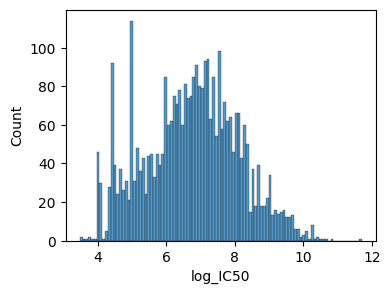

In [ ]:
# observe the distribution of the log transformed feature.
plt.figure(figsize=(4,3))
sns.histplot(act_df2['log_IC50'], bins=100)
plt.show()

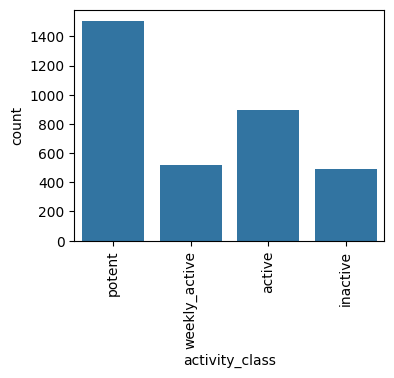

In [ ]:
# determine the number of compounds per activity class and plot it.
plt.figure(figsize=(4,3))
sns.countplot(x='activity_class', data=act_df2)
plt.xticks(rotation=90)
plt.show()

In [ ]:
# select only required features.
features_needed = ['molecule_chembl_id','canonical_smiles','log_IC50', 'activity_class']
act_df3 = act_df2[features_needed]
act_df3.head()

,molecule_chembl_id,canonical_smiles,log_IC50,activity_class
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,8.744727,potent
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,9.045757,potent
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,7.879426,potent
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,8.920819,potent
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,5.724919,weekly_active


##**2. Exploratory Data Analysis (EDA)**

### To calculate the Lipnski descriptors install rdkit.
##**Install rdkit**

In [ ]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 34.4 MB/s eta 0:00:00


In [ ]:
# import chem and then Lipinski from chem.
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [ ]:
# Add the RDKit molecule for each compound by using the Chem.MolFromSmiles function.
act_df3["mol"] = act_df3["canonical_smiles"].apply(Chem.MolFromSmiles)
act_df3.head(3)

/tmp/ipykernel_2343/1274593536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["mol"] = act_df3["canonical_smiles"].apply(Chem.MolFromSmiles)


,molecule_chembl_id,canonical_smiles,log_IC50,activity_class,mol
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,8.744727,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db7fed0>
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,9.045757,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db8cdd0>
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,7.879426,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db8ca50>


In [ ]:
# calculate the descriptors based on mol
act_df3["MW"] = act_df3["mol"].apply(Descriptors.MolWt)
act_df3["LogP"] = act_df3["mol"].apply(Descriptors.MolLogP)
act_df3["HBD"] = act_df3["mol"].apply(Descriptors.NumHDonors)
act_df3["HBA"] = act_df3["mol"].apply(Descriptors.NumHAcceptors)
act_df3.head(3)

/tmp/ipykernel_2343/2253237638.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["MW"] = act_df3["mol"].apply(Descriptors.MolWt)
/tmp/ipykernel_2343/2253237638.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["LogP"] = act_df3["mol"].apply(Descriptors.MolLogP)
/tmp/ipykernel_2343/2253237638.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

,molecule_chembl_id,canonical_smiles,log_IC50,activity_class,mol,MW,LogP,HBD,HBA
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,8.744727,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db7fed0>,477.467,3.8041,2,5
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,9.045757,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db8cdd0>,521.520,3.1909,2,6
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,7.879426,potent,<rdkit.Chem.rdchem.Mol object at 0x7b341db8ca50>,534.519,2.6839,2,6


In [ ]:
act_df3.to_csv("gsecretase_bioactivity_data_preprocessed.csv", index=False)

## **MW**

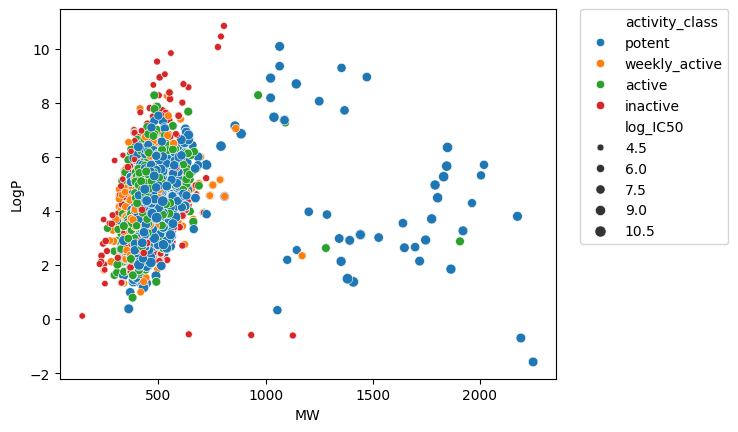

<Figure size 640x480 with 0 Axes>

In [ ]:
# observe the cistribution of the molecular weight and logP values of the compounds using scatter plot.
sns.scatterplot(x='MW', y='LogP', data=act_df3, hue='activity_class', size='log_IC50')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()
plt.savefig('MW_vs_LogP.png')

In [ ]:
# create a df for each class.
potent = act_df3[act_df3['activity_class'] == 'potent']['MW']
active = act_df3[act_df3['activity_class'] == 'active']['MW']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['MW']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['MW']
groups = [potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for molecular weight.
from scipy.stats import kruskal
h_stat, p_value = kruskal(*groups)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value)) # there is a highly significant difference between the groups.

Statistics=115.571, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=act_df3['MW'], groups=act_df3['activity_class'])
print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1      group2    meandiff p-adj   lower    upper   reject
---------------------------------------------------------------
  active      inactive  -11.047 0.6739 -36.2792  14.1852  False
  active        potent  43.3772    0.0  24.4376  62.3169   True
  active weekly_active  -4.4251 0.9677 -29.1671  20.3169  False
inactive        potent  54.4242    0.0  31.0676  77.7808   True
inactive weekly_active   6.6218 0.9314 -21.6445  34.8882  False
  potent weekly_active -47.8024    0.0 -70.6285 -24.9762   True
---------------------------------------------------------------


In [ ]:
# convert the tukey summary to df and export as csv.
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],  # skip header
    columns=tukey._results_table.data[0])
tukey_df.to_csv("tukey_results.csv", index=False)
tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,active,inactive,-11.0470,0.6739,-36.2792,14.1852,False
1,active,potent,43.3772,0.0000,24.4376,62.3169,True
2,active,weekly_active,-4.4251,0.9677,-29.1671,20.3169,False
3,inactive,potent,54.4242,0.0000,31.0676,77.7808,True
4,inactive,weekly_active,6.6218,0.9314,-21.6445,34.8882,False
5,potent,weekly_active,-47.8024,0.0000,-70.6285,-24.9762,True


## **LogP**

In [ ]:
# create a df for each class.
potent = act_df3[act_df3['activity_class'] == 'potent']['LogP']
active = act_df3[act_df3['activity_class'] == 'active']['LogP']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['LogP']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['LogP']
groups_logP = [potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for LogP.
h_stat, p_value = kruskal(*groups_logP)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=33.504, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['LogP'], groups=act_df3['activity_class'])
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1      group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------
  active      inactive   0.1484  0.214 -0.0488  0.3456  False
  active        potent  -0.2343 0.0003 -0.3823 -0.0863   True
  active weekly_active  -0.2114 0.0257 -0.4048  -0.018   True
inactive        potent  -0.3827    0.0 -0.5652 -0.2001   True
inactive weekly_active  -0.3598 0.0002 -0.5807 -0.1389   True
  potent weekly_active   0.0229 0.9877 -0.1555  0.2013  False
-------------------------------------------------------------


## **HBD**

In [ ]:
# create a df for each class.
potent = act_df3[act_df3['activity_class'] == 'potent']['HBD']
active = act_df3[act_df3['activity_class'] == 'active']['HBD']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['HBD']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['HBD']
groups_hbd = [potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for HBD.
h_stat, p_value = kruskal(*groups_hbd)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=46.153, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['HBD'], groups=act_df3['activity_class'])
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1      group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------
  active      inactive  -0.1387 0.6595 -0.4492  0.1718  False
  active        potent   0.4701    0.0   0.237  0.7031   True
  active weekly_active    0.087 0.8833 -0.2175  0.3915  False
inactive        potent   0.6088    0.0  0.3214  0.8962   True
inactive weekly_active   0.2257  0.341 -0.1221  0.5736  False
  potent weekly_active  -0.3831 0.0026  -0.664 -0.1022   True
-------------------------------------------------------------


## **HBA**

In [ ]:
# create a df for each class.
potent = act_df3[act_df3['activity_class'] == 'potent']['HBA']
active = act_df3[act_df3['activity_class'] == 'active']['HBA']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['HBA']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['HBA']
groups_hba = [potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for HBA.
h_stat, p_value = kruskal(*groups_hba)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=77.748, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['HBA'], groups=act_df3['activity_class'])
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1      group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------
  active      inactive   -0.541 0.0001 -0.8639 -0.2181   True
  active        potent   0.3473 0.0013  0.1049  0.5896   True
  active weekly_active  -0.1095 0.8107 -0.4261  0.2071  False
inactive        potent   0.8883    0.0  0.5894  1.1872   True
inactive weekly_active   0.4315 0.0117  0.0698  0.7932   True
  potent weekly_active  -0.4568 0.0003 -0.7489 -0.1647   True
-------------------------------------------------------------


## **3. Descriptor Calculation and Dataset Preparation**

### The fingerprints of the compounds are caclulated to be used for the machine learning.

In [ ]:
! pip install mordredcommunity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 9.7 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem


In [ ]:
from mordred import Calculator, descriptors

In [ ]:
# from act_df3 df slice the chambel_id and canonical_smile features and save as .smi.
selected_features = ['molecule_chembl_id','canonical_smiles']
molecules = act_df3[selected_features]
molecules.to_csv('molecule.smi', sep='\t', index=False, header=False)

In [ ]:
! cat molecule.smi | head -5

CHEMBL336071	C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2NC1=O
CHEMBL336813	C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2N(CCO)C1=O
CHEMBL334594	C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2N(CC(N)=O)C1=O
CHEMBL133237	C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(=O)ccoc3c2)c2ccccc2N(C)C1=O
CHEMBL132900	C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)CCN(C)C3=O)c2ccccc2N(C)C1=O


In [ ]:
molecules.columns = ['ID','SMILES']
molecules.head()

,ID,SMILES
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...


In [ ]:
# create the colecule for which the descriptors are calculated.
mols = [Chem.MolFromSmiles(s) for s in molecules['SMILES']]
# # Calculate descriptors
calc = Calculator(descriptors, ignore_3D=True)
desc_df = calc.pandas(mols)

100%|██████████| 3416/3416 [16:45<00:00,  3.40it/s]


In [ ]:
# convert all columns of the desc_df to float
desc_df = desc_df.astype(float)
desc_df.info()

<class 'mordred._base.pandas_module.MordredDataFrame'>
RangeIndex: 3416 entries, 0 to 3415
Columns: 1613 entries, ABC to mZagreb2
dtypes: float64(1613)
memory usage: 42.0 MB


In [ ]:
desc_df.head()

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,27.841033,21.168456,0.0,0.0,45.699901,2.470279,4.865777,45.699901,1.305711,4.497669,...,10.494020,85.629872,477.150013,8.520536,3820.0,61.0,190.0,226.0,10.694444,7.527778
1,29.881473,23.104097,0.0,0.0,49.682902,2.499472,4.908497,49.682902,1.307445,4.573582,...,10.592501,89.050088,521.176227,8.272639,4583.0,68.0,204.0,244.0,12.055556,8.333333
2,30.807359,23.816919,0.0,0.0,50.413264,2.501937,4.913317,50.413264,1.292648,4.598884,...,10.614892,90.180281,534.171476,8.478912,4876.0,69.0,210.0,250.0,12.916667,8.416667
3,30.059812,22.355273,0.0,0.0,49.452603,2.494062,4.933257,49.452603,1.301384,4.574908,...,10.644115,83.363138,515.165663,8.445339,4689.0,71.0,206.0,247.0,12.666667,8.194444
4,30.835869,22.913759,0.0,0.0,50.763375,2.498261,4.951010,50.763375,1.301625,4.600382,...,10.690967,84.539900,530.212947,7.913626,5049.0,74.0,212.0,255.0,13.527778,8.388889


##**Clean the descriptors**

In [ ]:
# calculate the mean percentage of nulls per descriptor.
missing_pct = desc_df.isnull().mean() * 100
desc_df_filtered = desc_df.loc[:, missing_pct < 20]
desc_df_filtered.shape

(3416, 1445)

### instead of droping descriptors with some null values, impute the values with median. This helps to prevent the loss of compounds.

In [ ]:
# fill the missing values by the median of each descriptor.
clean_df = desc_df_filtered.fillna(desc_df_filtered.median())
clean_df.shape

(3416, 1445)

## **4. ML with RandomForest regression model**

In [ ]:
# import the necessart lobraries
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Determine the numerical imput features X and target feature y
clean_df
y = act_df3['log_IC50']
print(clean_df.shape)
print(y.shape)

(3416, 1445)
(3416,)


In [ ]:
# The dataframe has 1613 features or desscriptors. Drop if there are non informative features.
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_df = selection.fit_transform(clean_df)
df_filt = pd.DataFrame(X_df)
print(df_filt.shape)

(3416, 725)


In [ ]:
# remove highly correlated features.
corr_matrix = df_filt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

In [ ]:
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_filt = df_filt.drop(columns=to_drop)
print(df_filt.shape)

(3416, 324)


In [ ]:
# scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filt)

## The variance threshold removed nearly 800 features.

In [ ]:
X = df_filt

In [ ]:
# split X aand y to train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2732, 324)
(684, 324)
(2732,)
(684,)


In [105]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [106]:
accuracy = r2_score(y_test, y_pred)
accuracy

0.5815101476782493

In [ ]:
# use random forest for regression.
model = RandomForestRegressor(n_estimators=100, random_state=42)
score = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R² scores:", score)
print("Mean R²:", score.mean())
print("Std R²:", score.std())

R² scores: [ 0.25119397  0.36445748 -0.03785619  0.3588243   0.04165265]
Mean R²: 0.1956544417452669
Std R²: 0.16519520058466497


In [ ]:
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [107]:
accuracy1 = r2_score(y_test, y_pred)
accuracy1

0.5815101476782493

##**Compare difference regressors**

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
models = {"Ridge": Ridge(), "Lasso": Lasso(), "ElasticNet": ElasticNet(), "RandomForest": RandomForestRegressor(random_state=42),
"ExtraTrees": ExtraTreesRegressor(random_state=42)}
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    results.append({"Model": name, "Mean_R2": scores.mean(), "Std_R2": scores.std()})
results_df = pd.DataFrame(results)

print(results_df.sort_values("Mean_R2", ascending=False))